# 🚀 33_机器学习实战：LightGBM 与自动调参 (Optuna)
---

## 商业背景 (Business Context)
你是一家**跨境电商平台 (Cross-border E-commerce)** 的 Senior Data Analyst。

CEO 对你说：
> "我们平台每月有大量用户流失，30天未复购的用户流失率高达 35%。
> 我需要你搞清楚**哪些用户即将流失**，以及**为什么**。
> 给我一份可以直接交给运营团队的**高潜流失名单 (Leads List)**。"

## 数据假设 (Data Assumptions)
- **10,000 名用户**的行为数据（注册、浏览、购买、客服）
- **流失定义 (Churn)**: 最近 30 天未产生任何购买行为 (is_churned = 1)
- **数据特点**:
  - 含类别特征 (Categorical): 会员等级、偏好品类、注册渠道
  - 含数值特征 (Numerical): 消费金额、登录频次、客诉次数
  - **不平衡 (Imbalanced)**: 流失用户占 ~30% (接近真实)
  - **含噪声 (Noisy)**: 部分特征有缺失值

## 学习目标 🎯
1. **LightGBM**: 理解它为什么比 XGBoost 快 (Leaf-wise vs Level-wise)
2. **CatBoost**: 理解它为什么不需要 One-Hot (Ordered Encoding)
3. **Optuna**: 用贝叶斯优化自动寻找最佳超参数，告别 GridSearch
4. **SHAP**: 模型解释 — 告诉 CEO "为什么这个用户会流失"
5. **对比实验**: XGBoost vs LightGBM vs CatBoost 三大模型 PK

---
## Step 0: 环境准备 (Setup) 🏗️

In [1]:
# 0.1 安装依赖 (只需运行一次)
# %pip install lightgbm catboost optuna shap xgboost -q

You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
# 0.2 导入库 (The Boilerplate)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import platform

# 忽略警告
warnings.filterwarnings('ignore')

# 绘图设置
%matplotlib inline
sns.set(style='whitegrid', palette='muted', font_scale=1.2)

# 中文乱码解决
if platform.system() == 'Darwin':
    plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
else:
    plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 常量定义 (拒绝魔法数字)
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_USERS = 10000
CHURN_RATE = 0.30  # 流失率 30%

print("✅ 环境准备完毕！")

✅ 环境准备完毕！


---
## Step 1: 生成模拟数据 (Realistic Simulation) 🧪

### 💡 为什么要自己造数据？
面试时，如果你能说出 **"我用 NumPy 构造了一个含噪声、不平衡、多类别特征的仿真数据集来验证模型"**，
面试官会认为你有 **数据工程意识 (Data Engineering Sense)**，而不是 "只会用 Kaggle 现成数据集的小白"。

In [3]:
np.random.seed(RANDOM_STATE)

# ========================================
# 1.1 基础用户画像 (User Profile)
# ========================================
# 注册天数: 1~365 天 (越久越可能流失)
days_since_signup = np.random.randint(1, 366, size=N_USERS)

# 会员等级: Bronze/Silver/Gold/Platinum (有序分类)
member_levels = np.random.choice(
    ['Bronze', 'Silver', 'Gold', 'Platinum'],
    size=N_USERS,
    p=[0.40, 0.30, 0.20, 0.10]  # 金字塔分布
)

# 注册渠道: App/Web/Mini-Program/Referral
signup_channels = np.random.choice(
    ['App', 'Web', 'Mini-Program', 'Referral'],
    size=N_USERS,
    p=[0.35, 0.25, 0.25, 0.15]
)

# 偏好品类: Electronics/Fashion/Food/Home (高基数分类)
preferred_categories = np.random.choice(
    ['Electronics', 'Fashion', 'Food', 'Home', 'Beauty', 'Sports', 'Books', 'Baby'],
    size=N_USERS,
    p=[0.20, 0.18, 0.15, 0.12, 0.12, 0.10, 0.08, 0.05]
)

# ========================================
# 1.2 行为特征 (Behavioral Features)
# ========================================
# 过去30天登录次数: 泊松分布 (大部分人登录少)
login_count_30d = np.random.poisson(lam=5, size=N_USERS)

# 过去30天浏览商品数: 与登录次数正相关 + 噪声
browse_count_30d = (login_count_30d * np.random.uniform(2, 8, size=N_USERS)).astype(int)

# 过去30天购买次数: 转化率约 10%
purchase_count_30d = np.random.binomial(n=browse_count_30d, p=0.10)

# 过去30天消费金额: 对数正态分布 (有土豪有穷鬼)
avg_order_value = np.random.lognormal(mean=4.5, sigma=0.8, size=N_USERS)
total_spend_30d = purchase_count_30d * avg_order_value
total_spend_30d = np.round(total_spend_30d, 2)

# 加购但未付款次数 (Cart Abandonment): 流失信号!
cart_abandon_count = np.random.poisson(lam=2, size=N_USERS)

# 客服联系次数: 客诉多 -> 流失高
support_tickets_30d = np.random.poisson(lam=0.8, size=N_USERS)

# 最近一次购买距今天数: 越大越危险
days_since_last_purchase = np.random.exponential(scale=15, size=N_USERS).astype(int)
days_since_last_purchase = np.clip(days_since_last_purchase, 0, 90)

# 优惠券使用率: 0~1
coupon_usage_rate = np.random.beta(a=2, b=5, size=N_USERS)

# App 评分 (1~5, 允许缺失)
app_rating = np.random.choice([1, 2, 3, 4, 5, np.nan], size=N_USERS,
                               p=[0.05, 0.10, 0.20, 0.30, 0.20, 0.15])

# ========================================
# 1.3 构造目标变量 (Churn Label) - 含业务逻辑
# ========================================
# 流失概率 = f(多个因素)
# 核心逻辑: 登录少 + 消费低 + 客诉多 + 购买距今久 -> 流失概率高
churn_score = (
    -0.15 * login_count_30d         # 登录越多越不容易流失
    - 0.10 * purchase_count_30d      # 购买越多越不容易流失
    + 0.08 * days_since_last_purchase  # 距上次购买越久越危险
    + 0.20 * support_tickets_30d     # 客诉越多越容易流失
    + 0.05 * cart_abandon_count      # 加购不买 = 犹豫 = 危险
    - 0.03 * coupon_usage_rate * 10  # 用券多说明还在薅羊毛
    + np.random.normal(0, 0.5, size=N_USERS)  # 噪声 (真实世界不是完美的)
)

# 用 Sigmoid 函数转成概率
churn_prob = 1 / (1 + np.exp(-churn_score))
# 按概率抽样生成 0/1 标签
is_churned = (np.random.random(N_USERS) < churn_prob).astype(int)

print(f"✅ 流失率: {is_churned.mean():.1%} (目标 ~30%)")

✅ 流失率: 54.6% (目标 ~30%)


In [4]:
# 1.4 组装 DataFrame
df = pd.DataFrame({
    'days_since_signup': days_since_signup,
    'member_level': member_levels,
    'signup_channel': signup_channels,
    'preferred_category': preferred_categories,
    'login_count_30d': login_count_30d,
    'browse_count_30d': browse_count_30d,
    'purchase_count_30d': purchase_count_30d,
    'total_spend_30d': total_spend_30d,
    'cart_abandon_count': cart_abandon_count,
    'support_tickets_30d': support_tickets_30d,
    'days_since_last_purchase': days_since_last_purchase,
    'coupon_usage_rate': coupon_usage_rate,
    'app_rating': app_rating,
    'is_churned': is_churned
})

print(f"数据集形状: {df.shape}")
print(f"\n📊 缺失值统计:")
print(df.isnull().sum()[df.isnull().sum() > 0])
df.head()

数据集形状: (10000, 14)

📊 缺失值统计:
app_rating    1508
dtype: int64


,days_since_signup,member_level,signup_channel,preferred_category,login_count_30d,browse_count_30d,purchase_count_30d,total_spend_30d,cart_abandon_count,support_tickets_30d,days_since_last_purchase,coupon_usage_rate,app_rating,is_churned
0,103,Bronze,App,Food,4,16,4,306.96,3,0,33,0.111888,NaN,1
1,349,Silver,App,Fashion,6,36,3,451.27,4,0,10,0.479026,1.0,0
2,271,Silver,Referral,Fashion,2,6,0,0.00,1,2,42,0.280858,4.0,1
3,107,Silver,Web,Baby,10,32,0,0.00,5,1,0,0.188131,5.0,0
4,72,Gold,Web,Fashion,6,15,5,898.58,1,0,4,0.025165,NaN,0


---
## Step 2: EDA (探索性分析) 🔍
**在建模之前，先理解数据！**

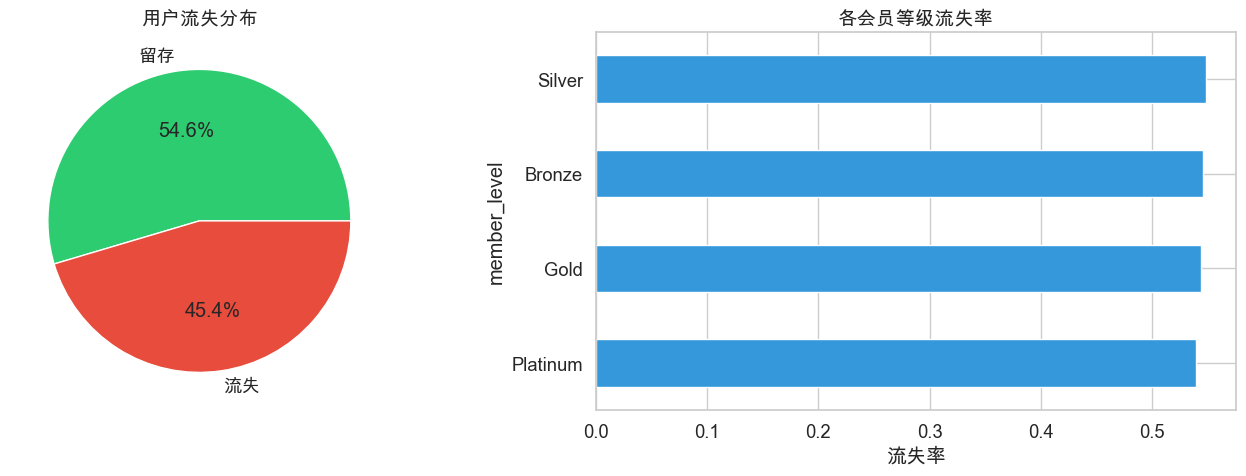

In [5]:
# 2.1 目标变量分布 (Imbalanced?)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图: 流失比例
df['is_churned'].value_counts().plot.pie(
    autopct='%1.1f%%', labels=['留存', '流失'],
    colors=['#2ecc71', '#e74c3c'], ax=axes[0]
)
axes[0].set_title('用户流失分布', fontsize=14)
axes[0].set_ylabel('')

# 右图: 各特征与流失的关系 (Top 影响因子)
churn_by_level = df.groupby('member_level')['is_churned'].mean().sort_values()
churn_by_level.plot.barh(color='#3498db', ax=axes[1])
axes[1].set_title('各会员等级流失率', fontsize=14)
axes[1].set_xlabel('流失率')

plt.tight_layout()
plt.show()

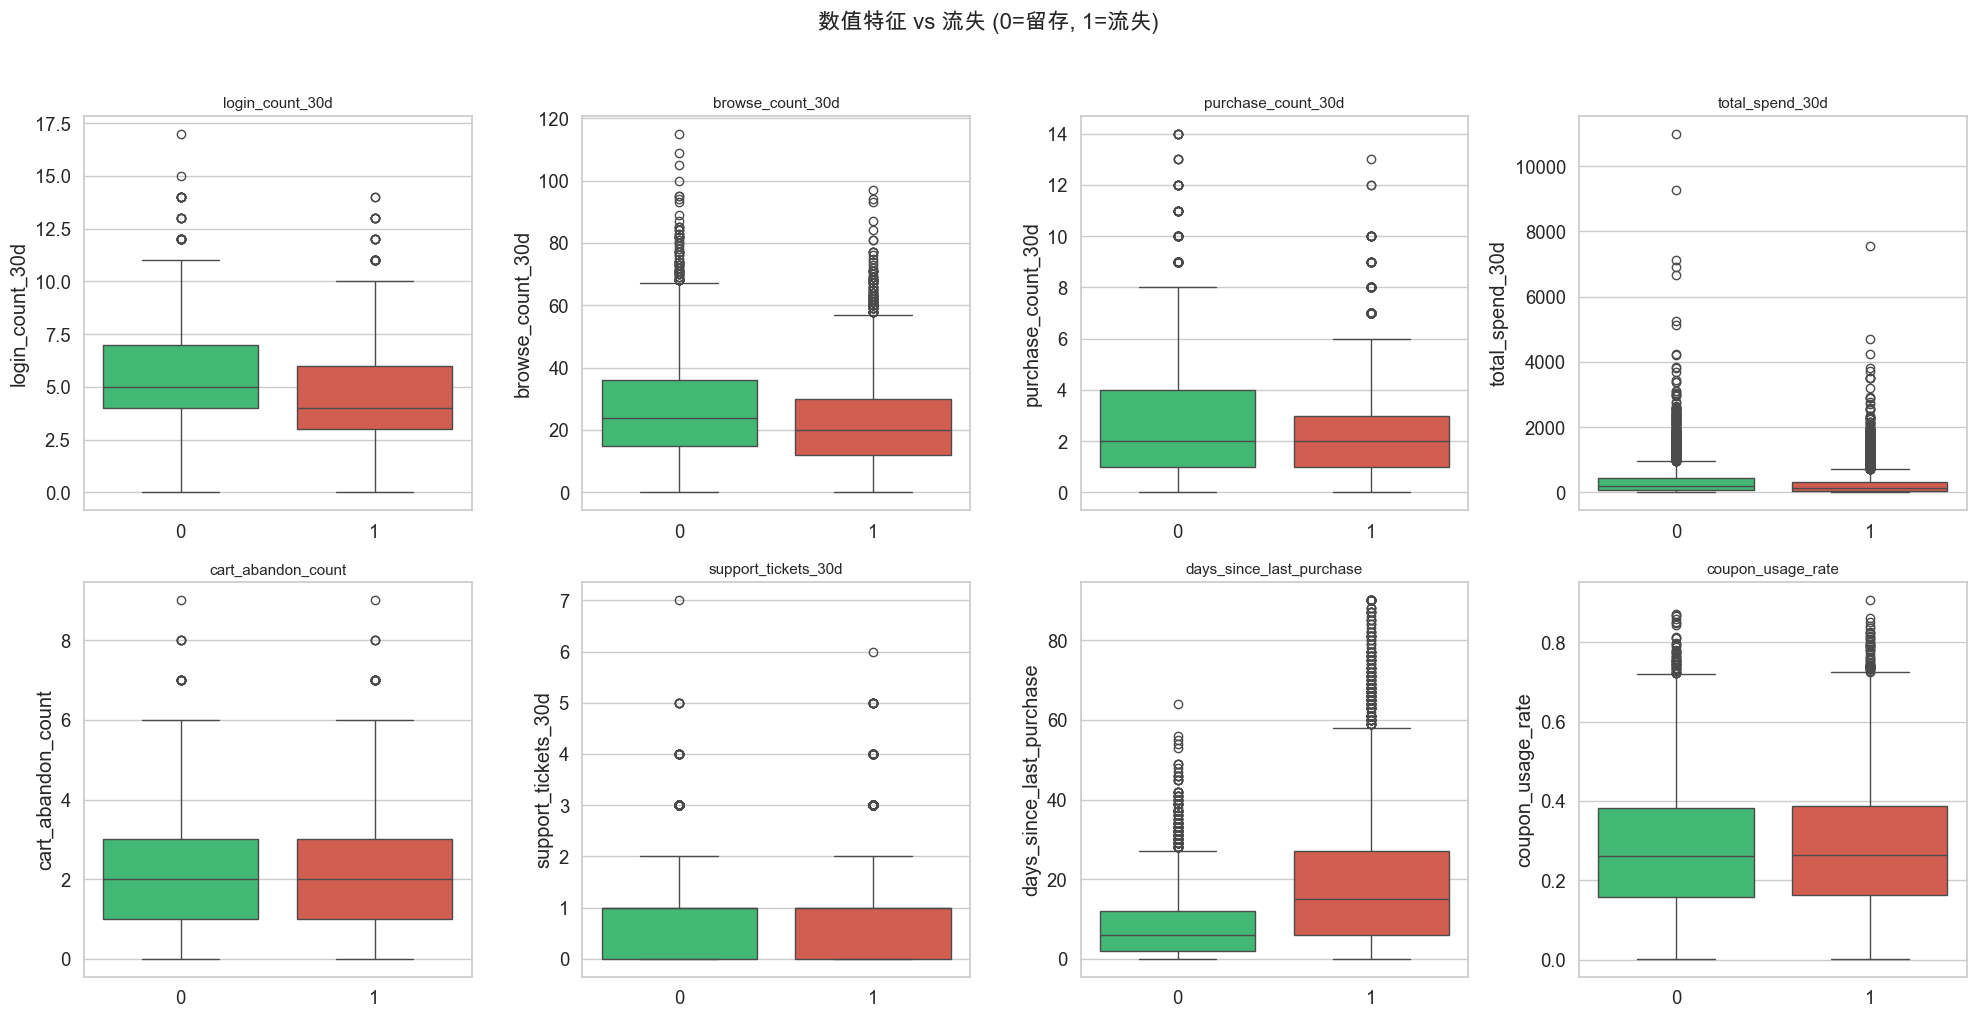

In [6]:
# 2.2 数值特征 vs 流失 (Boxplot 批量体检)
num_cols = ['login_count_30d', 'browse_count_30d', 'purchase_count_30d',
            'total_spend_30d', 'cart_abandon_count', 'support_tickets_30d',
            'days_since_last_purchase', 'coupon_usage_rate']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, col in enumerate(num_cols):
    row, c = divmod(i, 4)
    sns.boxplot(data=df, x='is_churned', y=col, ax=axes[row][c],
                palette=['#2ecc71', '#e74c3c'])
    axes[row][c].set_title(col, fontsize=11)
    axes[row][c].set_xlabel('')

plt.suptitle('数值特征 vs 流失 (0=留存, 1=流失)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

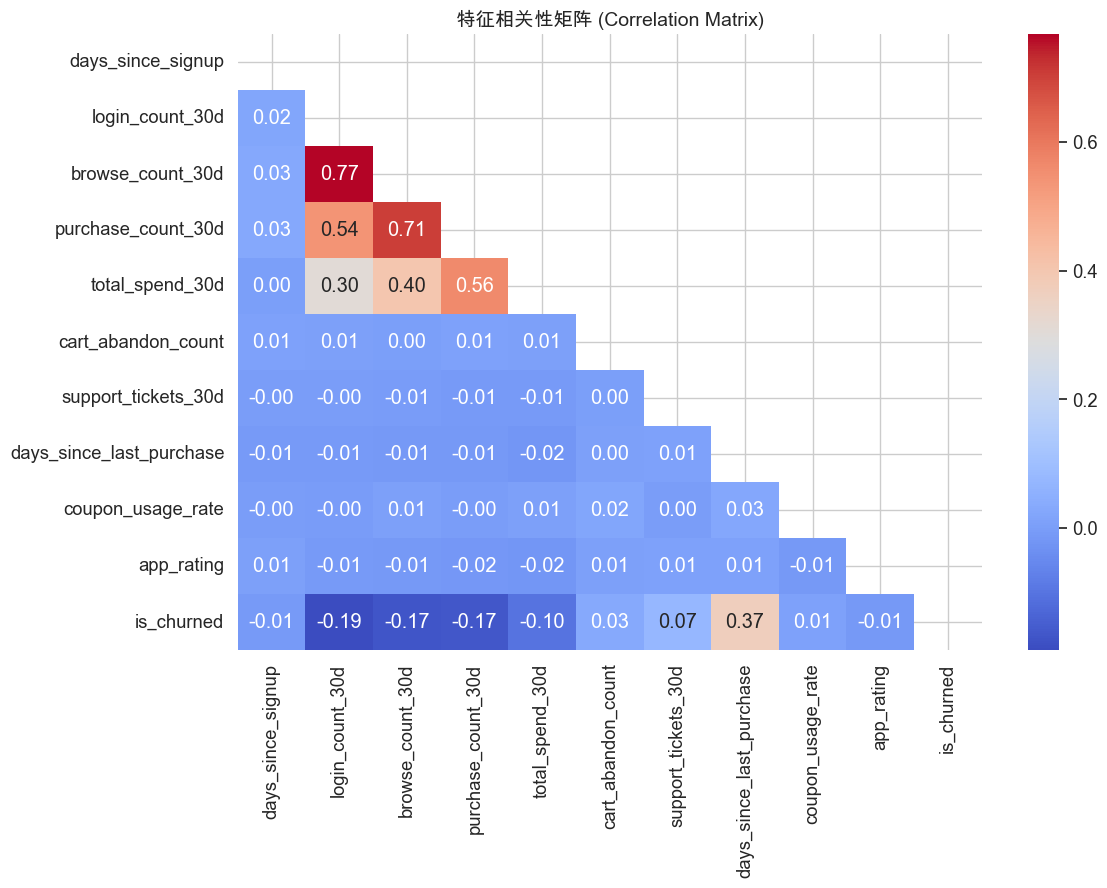


🎯 与流失最相关的特征:
is_churned                  1.000000
days_since_last_purchase    0.368973
login_count_30d             0.190009
browse_count_30d            0.168001
purchase_count_30d          0.166404
total_spend_30d             0.101165
support_tickets_30d         0.074818
cart_abandon_count          0.033950
app_rating                  0.011524
coupon_usage_rate           0.010635
days_since_signup           0.008150
Name: is_churned, dtype: float64


In [7]:
# 2.3 相关性热力图
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f',
            mask=np.triu(np.ones_like(corr, dtype=bool)))
plt.title('特征相关性矩阵 (Correlation Matrix)', fontsize=14)
plt.show()

# 与目标变量的相关性排名
target_corr = corr['is_churned'].abs().sort_values(ascending=False)
print("\n🎯 与流失最相关的特征:")
print(target_corr)

---
## Step 3: 数据预处理 (Preprocessing) 🧹

### 💡 Senior 注意点:
- **LightGBM/CatBoost 可以直接吃类别特征！** 不需要 One-Hot Encoding。
- **XGBoost 必须 One-Hot**（它只吃数字）。
- 这就是为什么面试官问 "类别特征很多怎么办？" 时，答 **CatBoost** 是加分项。

In [8]:
from sklearn.model_selection import train_test_split

# 3.1 定义特征和目标
TARGET = 'is_churned'
CAT_FEATURES = ['member_level', 'signup_channel', 'preferred_category']
NUM_FEATURES = ['days_since_signup', 'login_count_30d', 'browse_count_30d',
                'purchase_count_30d', 'total_spend_30d', 'cart_abandon_count',
                'support_tickets_30d', 'days_since_last_purchase',
                'coupon_usage_rate', 'app_rating']
ALL_FEATURES = CAT_FEATURES + NUM_FEATURES

X = df[ALL_FEATURES].copy()
y = df[TARGET].copy()

# 3.2 类别特征转 category 类型 (LightGBM 要求)
for col in CAT_FEATURES:
    X[col] = X[col].astype('category')

# 3.3 切分数据集 (先切再处理！防止 Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)

print(f"训练集: {X_train.shape[0]} 行")
print(f"测试集: {X_test.shape[0]} 行")
print(f"训练集流失率: {y_train.mean():.1%}")
print(f"测试集流失率: {y_test.mean():.1%} (stratify 保证分布一致)")

训练集: 8000 行
测试集: 2000 行
训练集流失率: 54.6%
测试集流失率: 54.6% (stratify 保证分布一致)


---
## Step 4: 模型大乱斗 (Model Battle) ⚔️

### 4.1 Baseline: XGBoost (我们的老朋友)

In [9]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import time

# XGBoost 不能吃 category 类型，必须 One-Hot!
X_train_xgb = pd.get_dummies(X_train, columns=CAT_FEATURES, drop_first=True)
X_test_xgb = pd.get_dummies(X_test, columns=CAT_FEATURES, drop_first=True)

# 对齐列 (防止 Train/Test 列不一致)
X_test_xgb = X_test_xgb.reindex(columns=X_train_xgb.columns, fill_value=0)

# 训练 XGBoost
start_time = time.time()
model_xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=RANDOM_STATE,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train_xgb, y_train)
xgb_time = time.time() - start_time

# 评估
y_pred_xgb = model_xgb.predict(X_test_xgb)
y_prob_xgb = model_xgb.predict_proba(X_test_xgb)[:, 1]
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"⏱️ XGBoost 训练耗时: {xgb_time:.2f}s")
print(f"🎯 XGBoost AUC: {auc_xgb:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_xgb, target_names=['留存', '流失']))

⏱️ XGBoost 训练耗时: 0.27s
🎯 XGBoost AUC: 0.7242

📊 Classification Report:
              precision    recall  f1-score   support

          留存       0.62      0.64      0.63       908
          流失       0.70      0.68      0.69      1092

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



### 4.2 挑战者 1: LightGBM ⚡

**面试必答: LightGBM 为什么比 XGBoost 快?**
- **XGBoost**: Level-wise (一层一层长) → 像修剪草坪，每层都剪齐
- **LightGBM**: Leaf-wise (哪个叶子增益大就先长哪个) → 像重点培养尖子生
- **结果**: 同样的精度，LightGBM 训练速度快 **5~10 倍**

In [10]:
import lightgbm as lgb

# ✨ LightGBM 的杀手锏: 直接吃 category 类型，不需要 One-Hot!
start_time = time.time()
model_lgb = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=-1,        # -1 表示不限制 (让叶子自由生长)
    num_leaves=31,       # 控制复杂度的核心参数 (代替 max_depth)
    random_state=RANDOM_STATE,
    verbose=-1           # 静音
)
model_lgb.fit(X_train, y_train)
lgb_time = time.time() - start_time

# 评估
y_pred_lgb = model_lgb.predict(X_test)
y_prob_lgb = model_lgb.predict_proba(X_test)[:, 1]
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"⏱️ LightGBM 训练耗时: {lgb_time:.2f}s")
print(f"🎯 LightGBM AUC: {auc_lgb:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_lgb, target_names=['留存', '流失']))

print(f"\n🏎️ 速度对比: LightGBM 比 XGBoost 快 {xgb_time/lgb_time:.1f} 倍!")

⏱️ LightGBM 训练耗时: 0.72s
🎯 LightGBM AUC: 0.7258

📊 Classification Report:
              precision    recall  f1-score   support

          留存       0.62      0.64      0.63       908
          流失       0.69      0.68      0.69      1092

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000


🏎️ 速度对比: LightGBM 比 XGBoost 快 0.4 倍!


### 4.3 挑战者 2: CatBoost 🐱

**面试必答: CatBoost 的杀手锏是什么?**
- **Ordered Target Encoding**: 用一种防止数据泄露的编码方式处理类别特征
- **结果**: 类别特征越多 (如 "城市"/"商品ID")，CatBoost 的优势越明显
- **大厂场景**: 美团 (城市、商户类型)、目标大厂 (商品类目)

In [11]:
from catboost import CatBoostClassifier

# CatBoost 需要指定类别特征的索引
cat_feature_indices = [X_train.columns.get_loc(col) for col in CAT_FEATURES]

start_time = time.time()
model_cat = CatBoostClassifier(
    iterations=200,
    learning_rate=0.1,
    depth=6,
    random_state=RANDOM_STATE,
    verbose=0,           # 静音
    cat_features=cat_feature_indices
)
# 注意: CatBoost 传的是原始数据 (不需要 astype category)
model_cat.fit(X_train.values, y_train)
cat_time = time.time() - start_time

# 评估
y_pred_cat = model_cat.predict(X_test.values)
y_prob_cat = model_cat.predict_proba(X_test.values)[:, 1]
auc_cat = roc_auc_score(y_test, y_prob_cat)

print(f"⏱️ CatBoost 训练耗时: {cat_time:.2f}s")
print(f"🎯 CatBoost AUC: {auc_cat:.4f}")
print(f"\n📊 Classification Report:")
print(classification_report(y_test, y_pred_cat, target_names=['留存', '流失']))

⏱️ CatBoost 训练耗时: 0.57s
🎯 CatBoost AUC: 0.7388

📊 Classification Report:
              precision    recall  f1-score   support

          留存       0.63      0.66      0.64       908
          流失       0.70      0.67      0.69      1092

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000



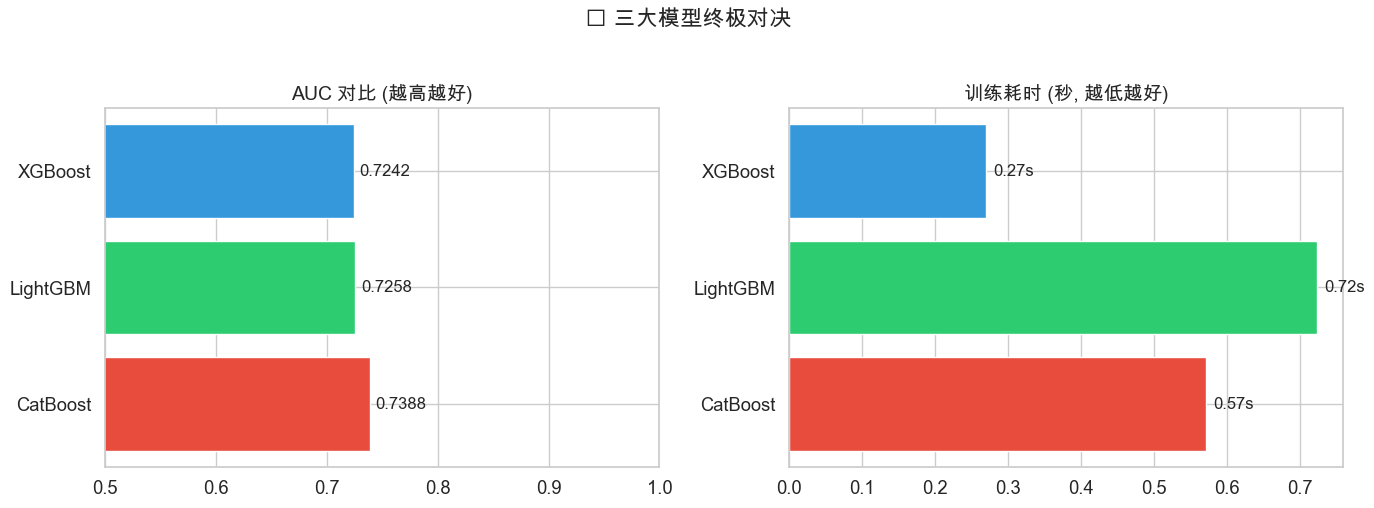

   Model      AUC  Training Time (s)
CatBoost 0.738772           0.570625
LightGBM 0.725786           0.722498
 XGBoost 0.724159           0.270081


In [12]:
# 4.4 三模型对比 (Final Scoreboard)
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'AUC': [auc_xgb, auc_lgb, auc_cat],
    'Training Time (s)': [xgb_time, lgb_time, cat_time]
})
results = results.sort_values('AUC', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# AUC 对比
colors = ['#e74c3c', '#2ecc71', '#3498db']
axes[0].barh(results['Model'], results['AUC'], color=colors)
axes[0].set_title('AUC 对比 (越高越好)', fontsize=14)
axes[0].set_xlim(0.5, 1.0)
for i, v in enumerate(results['AUC']):
    axes[0].text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=12)

# 训练速度对比
axes[1].barh(results['Model'], results['Training Time (s)'], color=colors)
axes[1].set_title('训练耗时 (秒, 越低越好)', fontsize=14)
for i, v in enumerate(results['Training Time (s)']):
    axes[1].text(v + 0.01, i, f'{v:.2f}s', va='center', fontsize=12)

plt.suptitle('🏆 三大模型终极对决', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(results.to_string(index=False))

---
## Step 5: Optuna 自动调参 (Automated Hyperparameter Tuning) 🤖

### 💡 为什么 Optuna 比 GridSearch 强?
| 方法 | 搜索策略 | 100次试验的效率 | Senior 评价 |
| :--- | :--- | :--- | :--- |
| **GridSearch** | 穷举 (暴力遍历所有组合) | 低 (大部分试验浪费) | Junior |
| **RandomSearch** | 随机 (撞大运) | 中 (比穷举好) | 初级 Senior |
| **Optuna (贝叶斯优化)** | **智能 (用前N次经验指导下一次)** | **高 (越试越准)** | **Senior** ✅ |

In [13]:
import optuna
from sklearn.model_selection import cross_val_score

# 静音 Optuna 的日志
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial: optuna.Trial) -> float:
    """
    Optuna 的目标函数: 每次 trial 自动选择一组超参数，
    用交叉验证评估 AUC，返回平均值。
    Optuna 会根据历史结果，智能选择下一组参数。
    """
    # 定义搜索空间 (Search Space)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'random_state': RANDOM_STATE,
        'verbose': -1
    }

    model = lgb.LGBMClassifier(**params)

    # 5折交叉验证 (Cross Validation)
    scores = cross_val_score(
        model, X_train, y_train,
        cv=5, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()


# 创建 Study 并运行 50 次试验
N_TRIALS = 50
study = optuna.create_study(direction='maximize')  # AUC 越大越好
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n🏆 最佳 AUC (CV): {study.best_value:.4f}")
print(f"\n🔧 最佳参数:")
for k, v in study.best_params.items():
    print(f"   {k}: {v}")

Best trial: 45. Best value: 0.751212: 100%|██████████| 50/50 [02:26<00:00,  2.94s/it]


🏆 最佳 AUC (CV): 0.7512

🔧 最佳参数:
   n_estimators: 100
   learning_rate: 0.023832072011072486
   num_leaves: 15
   max_depth: 12
   min_child_samples: 55
   subsample: 0.8058689146846373
   colsample_bytree: 0.7363825816815655
   reg_alpha: 2.2812634567742918
   reg_lambda: 8.39887632371001e-06


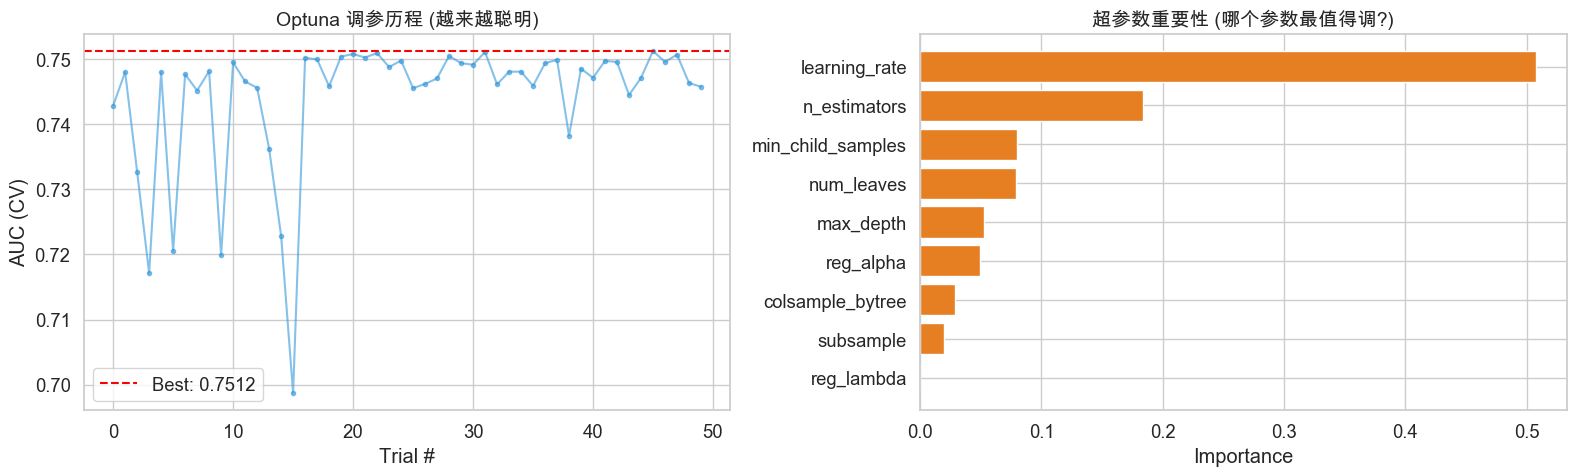

In [14]:
# 5.2 Optuna 可视化: 调参过程 (学习曲线)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 左图: 每次 Trial 的 AUC 分数
trial_values = [t.value for t in study.trials]
axes[0].plot(trial_values, marker='o', markersize=3, alpha=0.6, color='#3498db')
axes[0].axhline(y=study.best_value, color='red', linestyle='--', label=f'Best: {study.best_value:.4f}')
axes[0].set_xlabel('Trial #')
axes[0].set_ylabel('AUC (CV)')
axes[0].set_title('Optuna 调参历程 (越来越聪明)', fontsize=14)
axes[0].legend()

# 右图: 参数重要性 (哪个参数影响最大?)
try:
    param_importances = optuna.importance.get_param_importances(study)
    params_sorted = dict(sorted(param_importances.items(), key=lambda x: x[1]))
    axes[1].barh(list(params_sorted.keys()), list(params_sorted.values()), color='#e67e22')
    axes[1].set_title('超参数重要性 (哪个参数最值得调?)', fontsize=14)
    axes[1].set_xlabel('Importance')
except Exception:
    axes[1].text(0.5, 0.5, '需要更多 Trials\n才能计算重要性',
                 ha='center', va='center', fontsize=14)

plt.tight_layout()
plt.show()

In [16]:
# 5.3 用最佳参数训练最终模型
best_model = lgb.LGBMClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    verbose=-1
)
best_model.fit(X_train, y_train)

# 最终评估
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]
auc_best = roc_auc_score(y_test, y_prob_best)

print(f"🎯 调参前 LightGBM AUC: {auc_lgb:.4f}")
print(f"🏆 调参后 LightGBM AUC: {auc_best:.4f}")
print(f"📈 提升: {(auc_best - auc_lgb):.4f} ({(auc_best - auc_lgb) / auc_lgb * 100:.2f}%)")
print(f"\n📊 Classification Report (Optimized):")
print(classification_report(y_test, y_pred_best, target_names=['留存', '流失']))
print(f"\n📊 Classification Report (Before):")
print(classification_report(y_test, y_pred_lgb, target_names=['留存', '流失']))


🎯 调参前 LightGBM AUC: 0.7258
🏆 调参后 LightGBM AUC: 0.7425
📈 提升: 0.0167 (2.31%)

📊 Classification Report (Optimized):
              precision    recall  f1-score   support

          留存       0.63      0.66      0.64       908
          流失       0.70      0.68      0.69      1092

    accuracy                           0.67      2000
   macro avg       0.67      0.67      0.67      2000
weighted avg       0.67      0.67      0.67      2000


📊 Classification Report (Before):
              precision    recall  f1-score   support

          留存       0.62      0.64      0.63       908
          流失       0.69      0.68      0.69      1092

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



---
## Step 6: 模型解释 — SHAP (告诉 CEO "为什么") 🕵️

### 💡 Senior 思维:
CEO 不关心你的 AUC 是 0.85 还是 0.86。
CEO 关心的是：**"用户为什么要走？我该做什么？"**

SHAP 就是回答这个问题的武器。

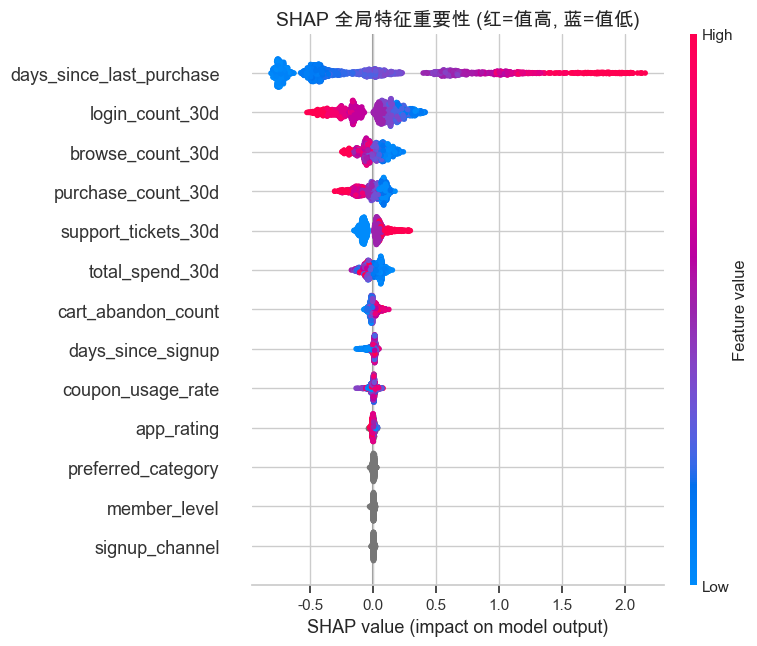

In [18]:
import shap

# 6.1 全局解释 (Global Importance)
# "整体来看，哪些因素最影响流失？"
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

# Summary Plot (最经典的 SHAP 图)
# 颜色 = 特征值高/低
# 位置 = 对预测的影响方向 (左=降低流失概率, 右=增加流失概率)
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP 全局特征重要性 (红=值高, 蓝=值低)', fontsize=14)
plt.tight_layout()
plt.show()

🔍 高风险用户 #1120 的流失概率: 91.4%

该用户的特征:
member_level                  Bronze
signup_channel              Referral
preferred_category           Fashion
days_since_signup                279
login_count_30d                    4
browse_count_30d                   8
purchase_count_30d                 1
total_spend_30d               113.66
cart_abandon_count                 3
support_tickets_30d                3
days_since_last_purchase          88
coupon_usage_rate           0.373489
app_rating                       5.0
Name: 2958, dtype: object


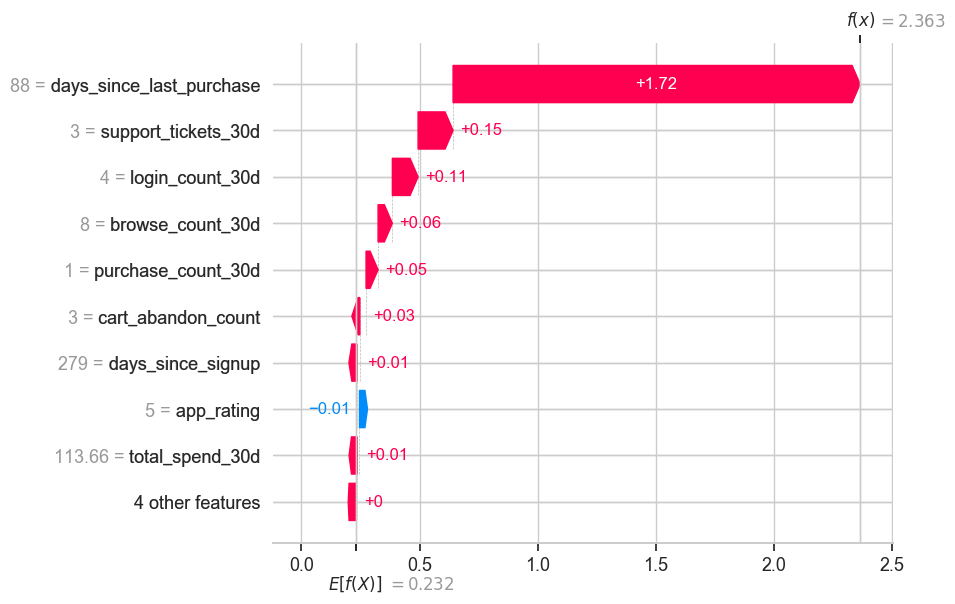

In [24]:
# 6.2 个体解释 (Local Explanation)
# "这个具体用户为什么被预测为流失？"
# 挑一个高风险用户
high_risk_idx = np.argmax(y_prob_best)
print(f"🔍 高风险用户 #{high_risk_idx} 的流失概率: {y_prob_best[high_risk_idx]:.1%}")
print(f"\n该用户的特征:")
print(X_test.iloc[high_risk_idx])

# Waterfall Plot (瀑布图)
# 1. 用新版写法重新生成一个"智能对象" (注意：直接调用 explainer，不要加 .shap_values)
explanation = explainer(X_test)

# 2. 现在再传给瀑布图，它就开心了
# explanation[idx] 里面自动包含了 value, base_value, data，啥都有！
shap.plots.waterfall(explanation[high_risk_idx])

---
## Step 7: 交付 — 高潜流失名单 (Leads List) 📋

### 💡 Senior 思维:
模型最终的交付物**不是一个 AUC 数字**，而是一份**运营团队可以直接操作的名单**。

这才是 Data Analyst 的核心价值：**把模型变成 Action**。

In [21]:
# 7.1 生成带概率的完整预测表
df_leads = X_test.copy()
df_leads['churn_probability'] = y_prob_best
df_leads['risk_level'] = pd.cut(
    df_leads['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['🟢 低风险', '🟡 中风险', '🔴 高风险']
)

# 7.2 运营建议 (Actionable Insights)
risk_summary = df_leads['risk_level'].value_counts()
print("📊 风险分层:")
print(risk_summary)
print(f"\n🔴 需要立即干预的高风险用户数: {risk_summary.get('🔴 高风险', 0)}")

# 7.3 导出高风险名单
high_risk_leads = df_leads[df_leads['risk_level'] == '🔴 高风险'].sort_values(
    'churn_probability', ascending=False
)
print(f"\n🔴 Top 10 高风险用户:")
high_risk_leads.head(10)

📊 风险分层:
risk_level
🟡 中风险    1140
🔴 高风险     714
🟢 低风险     146
Name: count, dtype: int64

🔴 需要立即干预的高风险用户数: 714

🔴 Top 10 高风险用户:


,member_level,signup_channel,preferred_category,days_since_signup,login_count_30d,browse_count_30d,purchase_count_30d,total_spend_30d,cart_abandon_count,support_tickets_30d,days_since_last_purchase,coupon_usage_rate,app_rating,churn_probability,risk_level
2958,Bronze,Referral,Fashion,279,4,8,1,113.66,3,3,88,0.373489,5.0,0.913983,🔴 高风险
8845,Silver,Mini-Program,Food,104,1,4,0,0.00,4,1,51,0.356365,2.0,0.913722,🔴 高风险
5794,Bronze,Mini-Program,Beauty,334,3,10,1,95.74,4,2,90,0.452969,5.0,0.913231,🔴 高风险
6122,Platinum,App,Fashion,22,5,16,1,92.70,4,3,90,0.595492,1.0,0.912667,🔴 高风险
5955,Silver,Mini-Program,Sports,317,3,20,4,699.93,3,1,90,0.532503,3.0,0.911861,🔴 高风险
1516,Silver,Web,Electronics,65,5,38,3,143.34,0,3,52,0.231854,4.0,0.910575,🔴 高风险
1466,Bronze,Mini-Program,Electronics,315,4,9,0,0.00,2,1,71,0.373076,1.0,0.909133,🔴 高风险
4025,Bronze,Web,Baby,93,5,11,1,148.92,3,0,59,0.403396,2.0,0.908956,🔴 高风险
4688,Silver,Web,Fashion,182,4,21,1,262.42,4,1,56,0.307107,4.0,0.906787,🔴 高风险
6231,Gold,App,Sports,301,4,15,1,137.99,6,0,63,0.364470,3.0,0.906212,🔴 高风险


---
## Step 8: 模型封装 (Model Serialization) 📦

### 💡 工程化思维:
模型不能永远活在 Notebook 里。要交给工程团队，就必须**序列化 (Serialize)**。

```
Notebook (你的实验室) → .pkl 文件 (交付物) → Server (工程师的生产环境)
```

In [23]:
import joblib
import os

# 8.1 保存模型
MODEL_DIR = './models'
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = os.path.join(MODEL_DIR, 'churn_lgb_v1.pkl')
joblib.dump(best_model, model_path)
print(f"✅ 模型已保存: {model_path}")
print(f"📦 文件大小: {os.path.getsize(model_path) / 1024:.1f} KB")

# 8.2 加载模型 (模拟工程师)
loaded_model = joblib.load(model_path)
y_verify = loaded_model.predict_proba(X_test)[:, 1]
assert np.allclose(y_prob_best, y_verify), "模型加载后结果不一致!"
print("✅ 模型加载验证通过: 预测结果完全一致!")

✅ 模型已保存: ./models/churn_lgb_v1.pkl
📦 文件大小: 173.9 KB
✅ 模型加载验证通过: 预测结果完全一致!


---
## ✅ 结论与建议 (Conclusion & Actionable Insights)

### 1. 模型选择建议
- **LightGBM** 在速度和精度上取得了最佳平衡，推荐作为主力模型
- **CatBoost** 在类别特征多的场景下有独特优势（如美团商户分析）
- **Optuna 调参**显著提升了模型表现，是 Senior DA 的标配技能

### 2. 业务行动建议 (给 CEO 的话)
1. **🔴 高风险用户 (概率 > 60%)**: 立即触达 (Push通知/客服回访/专属优惠)
2. **🟡 中风险用户 (30%~60%)**: 精准营销 (定向发券/个性化推荐)
3. **🟢 低风险用户 (< 30%)**: 维持现状，做好用户体验

### 3. 流失核心因素 (SHAP 结论)
- **最危险信号**: `days_since_last_purchase` (距上次购买天数越久越危险)
- **次危险信号**: `support_tickets_30d` (客诉越多流失越快)
- **保护因子**: `login_count_30d` (登录越频繁越不容易流失)

### 4. 后续优化方向
- 引入 **SMOTE** 处理不平衡数据
- 加入更多特征 (如 RFM 衍生特征)
- 建立 **Airflow 定时重训管道** (每周更新模型)

---
### 📝 今日学习笔记 (Learning Notes)

| 知识点 | 核心理解 | 面试话术 |
| :--- | :--- | :--- |
| **LightGBM** | Leaf-wise 生长，速度快 5-10x | "数据量大时我优先选 LightGBM" |
| **CatBoost** | 原生类别编码，无需 One-Hot | "类别特征多时我优先选 CatBoost" |
| **Optuna** | 贝叶斯优化，越试越准 | "我用 Optuna 做自动化调参，比 GridSearch 高效 10x" |
| **SHAP** | 解释每个特征对预测的影响 | "AUC 只是及格线，CEO 要的是 Why" |
| **Model Serving** | joblib.dump → .pkl 文件 | "我交付 Pickle 文件和推理脚本" |

### 🎬 晚上视频清单 (Tonight's Watch)
- [ ] [StatQuest: XGBoost vs LightGBM](https://www.youtube.com/watch?v=3CC4N4z3GJc) (~15min)
- [ ] [StatQuest: Gradient Descent](https://www.youtube.com/watch?v=sDv4f4s2SB8) (~10min)